## 0. Setup

In [7]:
# Core
import numpy as np
import pandas as pd
from pathlib import Path

# Stats / regressions
import statsmodels.formula.api as smf

# Plots
import matplotlib.pyplot as plt

#Speicherstruktur für Intermediate und Final Output
BASE_DIR = Path(
    "/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data"
)
BASE_DIR.mkdir(parents=True, exist_ok=True)

(TABLE_DIR := BASE_DIR / "tables").mkdir(exist_ok=True)
(DATA_DIR  := BASE_DIR / "intermediate").mkdir(exist_ok=True)

DUR_FILE = TABLE_DIR / "final_results_duration.xlsx"
SHOCK_FILE = TABLE_DIR / "shocks_ecb_mpd_me_d.csv"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## 1. Load durations + shocks

In [8]:
df_dur = pd.read_excel(DUR_FILE)
df_shk = pd.read_csv(SHOCK_FILE)

print("Durations:", df_dur.shape)
display(df_dur.head())

print("Shocks:", df_shk.shape)
display(df_shk.head())

Durations: (600, 17)


,RIC,CompanyName,CountryHQ,MarketCap,"Price (Dec 31, 2025)",ROE (%),Beta (5Y),Cost of Equity CAPM (%),CFPS FY25,CFPS FY26,CFPS FY27,CFPS FY28,CFPS FY29,Duration (r = 12.5%),Duration (CAPM r),Duration (undiscounted),Empirical Duration (2Y OIS)
0,A2.MI,A2A SpA,Italien,7610.187355,2.31,16.510875,0.880204,6.901022,0.57333,0.53667,0.57667,0.58,0.57,4.200683,2.723758,3.012927,0.040532
1,AAF.L,Airtel Africa PLC,Vereinigtes Königreich,15313.262664,355.20,12.926108,1.605701,10.528504,0.39500,0.46900,0.65650,0.70,0.81,13.936659,15.422047,3.350107,-0.038529
2,AAK.ST,AAK AB (publ),Schweden,6142.691574,263.80,18.980762,0.633045,5.665227,10.58000,16.16000,17.64333,20.70,NaN,11.129164,18.408584,2.744635,0.002520
3,AAL.L,Anglo American PLC,Vereinigtes Königreich,42523.693525,3085.00,-8.931006,1.830982,11.654909,3.65286,5.17800,5.57833,5.50,3.68,13.939346,14.514973,3.015951,-0.026897
4,AALB.AS,Aalberts NV,Niederlande,3222.012813,28.06,7.316883,1.322634,9.113171,4.07000,4.68000,4.95000,NaN,NaN,8.148887,9.672361,2.064234,-0.026285


Shocks: (312, 7)


,date,pc1,STOXX50,MP_pm,CBI_pm,MP_median,CBI_median
0,1999-01-07,-0.037546,-1.231443,-0.000000,-0.037546,0.020578,-0.058123
1,1999-01-21,0.003581,-0.212126,0.003581,0.000000,0.008569,-0.004988
2,1999-02-18,-0.000000,0.174157,-0.000000,-0.000000,-0.005565,0.005565
3,1999-03-04,-0.001926,0.082407,-0.001926,-0.000000,-0.003596,0.001670
4,1999-03-18,-0.000758,0.060922,-0.000758,-0.000000,-0.002326,0.001568


## 2. Clean & standardize keys (RIC + date)

In [9]:
# --- Firm key ---
df_dur["RIC"] = df_dur["RIC"].astype(str).str.strip()

# --- Shock event date ---
df_shk["date"] = pd.to_datetime(df_shk["date"], errors="coerce")
assert df_shk["date"].notna().all(), "Some ECB shock dates could not be parsed."

# Remove duplicates just in case (keep first)
df_shk = df_shk.drop_duplicates(subset=["date"]).sort_values("date").reset_index(drop=True)

display(df_shk[["date"]].head())
display(df_shk[["date"]].tail())

,date
0,1999-01-07
1,1999-01-21
2,1999-02-18
3,1999-03-04
4,1999-03-18


,date
307,2025-04-17
308,2025-06-05
309,2025-07-24
310,2025-09-11
311,2025-10-30


## 3. Pick the duration measure I’ll use in regressions

In [11]:
DUR_COL = "Duration (CAPM r)"   # <-- primary choice for main regressions
# alternatives:
# "Duration (r = 12.5%)"
# "Duration (undiscounted)"
# "Empirical Duration (2Y OIS)"

# Ensure numeric
df_dur[DUR_COL] = pd.to_numeric(df_dur[DUR_COL], errors="coerce")

print(df_dur[DUR_COL].describe())
print("Missing duration:", df_dur[DUR_COL].isna().mean())

count    491.000000
mean      14.132292
std        7.199553
min      -22.540059
25%       11.689167
50%       13.996469
75%       16.764795
max       82.918300
Name: Duration (CAPM r), dtype: float64
Missing duration: 0.18166666666666667


## 4. Inspect which ECB shock series to use

In [12]:
shock_cols = ["MP_pm", "CBI_pm", "MP_median", "CBI_median", "pc1", "STOXX50"]
avail = [c for c in shock_cols if c in df_shk.columns]

display(df_shk[["date"] + avail].describe())

# Correlation among candidate shocks (excluding date)
display(df_shk[avail].corr())

df_shk = df_shk.rename(columns={"MP_pm": "ShockMP", "CBI_pm": "ShockInfo"})

,date,MP_pm,CBI_pm,MP_median,CBI_median,pc1,STOXX50
count,312,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,2010-01-13 00:18:27.692307712,0.002615,0.000574,0.004240,-0.001052,0.003188,-0.082798
min,1999-01-07 00:00:00,-0.233329,-0.163802,-0.142502,-0.120139,-0.233329,-3.984675
25%,2002-10-03 00:00:00,0.000000,0.000000,-0.008852,-0.012103,-0.008872,-0.345728
50%,2009-03-19 00:00:00,0.000000,0.000000,0.001105,-0.000924,0.000545,-0.040156
75%,2016-02-02 06:00:00,0.002158,0.000000,0.015772,0.010020,0.014972,0.247892
max,2025-10-30 00:00:00,0.203563,0.200709,0.189967,0.137062,0.203563,2.006936
std,NaN,0.034716,0.026557,0.033077,0.028362,0.043675,0.680173


,MP_pm,CBI_pm,MP_median,CBI_median,pc1,STOXX50
MP_pm,1.000000,-0.001633,0.825494,0.259759,0.793881,-0.458662
CBI_pm,-0.001633,1.000000,0.171507,0.734344,0.606776,0.348630
MP_median,0.825494,0.171507,1.000000,0.004768,0.760453,-0.757823
CBI_median,0.259759,0.734344,0.004768,1.000000,0.653011,0.648840
pc1,0.793881,0.606776,0.760453,0.653011,1.000000,-0.152586
STOXX50,-0.458662,0.348630,-0.757823,0.648840,-0.152586,1.000000


## 5. Bring in firm returns

In [14]:
RET_FILE = DATA_DIR / "returns_daily.parquet"

df_ret = pd.read_parquet(RET_FILE)

df_ret["RIC"] = df_ret["RIC"].astype(str).str.strip()
df_ret["date"] = pd.to_datetime(df_ret["date"], errors="coerce")

# if your return column is named differently, adjust here
df_ret["ret"] = pd.to_numeric(df_ret["ret"], errors="coerce")

print(df_ret.shape)
display(df_ret.head())
print(df_ret.dtypes)

(1580203, 3)


,date,RIC,ret
0,2015-01-02,ADSGn.DE,-0.020826
1,2015-01-02,ALVG.DE,-0.004732
2,2015-01-02,BASFn.DE,-0.002719
3,2015-01-02,BAYGn.DE,0.0
4,2015-01-02,BC8G.DE,-0.004698


date    datetime64[ns]
RIC             object
ret            Float64
dtype: object


In [15]:
print("Missing dates:", df_ret["date"].isna().mean())
print("Missing ret:", df_ret["ret"].isna().mean())
print("Unique RICs:", df_ret["RIC"].nunique())
print("Date range:", df_ret["date"].min(), "→", df_ret["date"].max())

Missing dates: 0.0
Missing ret: 0.0
Unique RICs: 600
Date range: 2015-01-02 00:00:00 → 2025-12-31 00:00:00


In [ ]:
##  Querschnitts-Durchschnitt aller Aktien pro Tag

# 1) Ensure numeric returns
df_ret["ret"] = pd.to_numeric(df_ret["ret"], errors="coerce")

# 2) Cross-sectional market return per day
df_mkt = (
    df_ret
    .groupby("date", as_index=False)["ret"]
    .mean()
    .rename(columns={"ret": "mkt_ret"})
)

# 3) Merge back to firm-level data
df_ret = df_ret.merge(df_mkt, on="date", how="left")

# 4) Abnormal return
df_ret["AR"] = df_ret["ret"] - df_ret["mkt_ret"]

display(df_ret.head())

,date,RIC,ret,mkt_ret,AR
0,2015-01-02,ADSGn.DE,-0.020826,-0.001601,-0.019225
1,2015-01-02,ALVG.DE,-0.004732,-0.001601,-0.003131
2,2015-01-02,BASFn.DE,-0.002719,-0.001601,-0.001118
3,2015-01-02,BAYGn.DE,0.0,-0.001601,0.001601
4,2015-01-02,BC8G.DE,-0.004698,-0.001601,-0.003097


## 6. Construct the event-day panel (merge returns ↔ shocks ↔ durations)

In [20]:
# Keep only ECB event dates (day-0 window)
event_dates = set(df_shk["date"])
df_ret_evt = df_ret[df_ret["date"].isin(event_dates)].copy()

print("Returns on event dates:", df_ret_evt.shape)
print("Unique events in returns:", df_ret_evt["date"].nunique(), "out of", df_shk["date"].nunique())

# Merge shocks onto each firm-event observation
df_panel = df_ret_evt.merge(df_shk[["date", "ShockMP", "ShockInfo"]], on="date", how="left")

# Merge firm durations/controls
keep_cols = ["RIC", "CompanyName", "CountryHQ", "MarketCap", "Beta (5Y)", DUR_COL, "D_std"]
keep_cols = [c for c in keep_cols if c in df_dur.columns]
df_panel = df_panel.merge(df_dur[keep_cols], on="RIC", how="left")

print("Panel:", df_panel.shape)
display(df_panel.head())

Returns on event dates: (49104, 5)
Unique events in returns: 87 out of 312
Panel: (49104, 12)


,date,RIC,ret,mkt_ret,AR,ShockMP,ShockInfo,CompanyName,CountryHQ,MarketCap,Beta (5Y),Duration (CAPM r)
0,2015-01-22,A2.MI,0.008475,0.011444,-0.002969,-0.007489,-0.0,A2A SpA,Italien,7610.187355,0.880204,2.723758
1,2015-01-22,AAK.ST,0.014358,0.011444,0.002915,-0.007489,-0.0,AAK AB (publ),Schweden,6142.691574,0.633045,18.408584
2,2015-01-22,AAL.L,0.020954,0.011444,0.00951,-0.007489,-0.0,Anglo American PLC,Vereinigtes Königreich,42523.693525,1.830982,14.514973
3,2015-01-22,AALB.AS,0.008337,0.011444,-0.003107,-0.007489,-0.0,Aalberts NV,Niederlande,3222.012813,1.322634,9.672361
4,2015-01-22,ABBN.S,0.02054,0.011444,0.009096,-0.007489,-0.0,ABB Ltd,Schweiz,117283.176943,1.053171,15.216137


In [21]:
# Missingness
print("Missing AR:", df_panel["AR"].isna().mean())
print("Missing ShockMP:", df_panel["ShockMP"].isna().mean())
print("Missing ShockInfo:", df_panel["ShockInfo"].isna().mean())
print("Missing duration:", df_panel[DUR_COL].isna().mean())

Missing AR: 0.0
Missing ShockMP: 0.0
Missing ShockInfo: 0.0
Missing duration: 0.16540404040404041


In [24]:
DUR_COL = "Duration (CAPM r)"

# ensure numeric
df_panel[DUR_COL] = pd.to_numeric(df_panel[DUR_COL], errors="coerce")

# standardized duration (z-score)
df_panel["D_std"] = (df_panel[DUR_COL] - df_panel[DUR_COL].mean()) / df_panel[DUR_COL].std()

df_panel["D_std"].describe()

count    4.098200e+04
mean    -4.743656e-16
std      1.000000e+00
min     -5.146745e+00
25%     -3.443390e-01
50%     -1.376508e-02
75%      3.666528e-01
max      9.647729e+00
Name: D_std, dtype: float64

## 7. Baseline regression (single-shock interaction)

In [ ]:
# Make sure D_std exists
DUR_COL = "Duration (CAPM r)"
df_panel[DUR_COL] = pd.to_numeric(df_panel[DUR_COL], errors="coerce")
df_panel["D_std"] = (df_panel[DUR_COL] - df_panel[DUR_COL].mean()) / df_panel[DUR_COL].std()

# Keep only columns used in the regression + date for clustering
reg_cols = ["AR", "ShockMP", "D_std", "ln_mktcap", "Beta (5Y)", "date"]
df_reg = df_panel[reg_cols].copy()

# Drop rows with any missing values in these columns
df_reg = df_reg.dropna()

print("Regression sample:", df_reg.shape)
print("Unique event dates:", df_reg["date"].nunique())

formula = 'AR ~ ShockMP * D_std + ln_mktcap + Q("Beta (5Y)")'
m1 = smf.ols(formula, data=df_reg).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["date"]}   # IMPORTANT: use df_reg, not df_panel
)

print(m1.summary())

Regression sample: (40982, 6)
Unique event dates: 87
                            OLS Regression Results                            
Dep. Variable:                     AR   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     4.067
Date:                Fri, 16 Jan 2026   Prob (F-statistic):            0.00232
Time:                        12:35:07   Log-Likelihood:             1.0493e+05
No. Observations:               40982   AIC:                        -2.098e+05
Df Residuals:                   40976   BIC:                        -2.098e+05
Df Model:                           5                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

## 8.  Two-shock model (policy vs information)

In [27]:
formula2 = 'AR ~ ShockMP * D_std + ShockInfo * D_std + ln_mktcap + Q("Beta (5Y)")'

reg_cols2 = ["AR", "ShockMP", "ShockInfo", "D_std", "ln_mktcap", "Beta (5Y)", "date"]
df_reg2 = df_panel[reg_cols2].copy().dropna()

print("Regression sample (two-shock):", df_reg2.shape)
print("Unique event dates:", df_reg2["date"].nunique())

m2 = smf.ols(formula2, data=df_reg2).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg2["date"]}
)

print(m2.summary())

Regression sample (two-shock): (40982, 7)
Unique event dates: 87
                            OLS Regression Results                            
Dep. Variable:                     AR   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.251
Date:                Fri, 16 Jan 2026   Prob (F-statistic):            0.00414
Time:                        12:02:55   Log-Likelihood:             1.0493e+05
No. Observations:               40982   AIC:                        -2.098e+05
Df Residuals:                   40974   BIC:                        -2.098e+05
Df Model:                           7                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

## 9.  Robustness: alternative event window [0, +1]

In [30]:
DUR_COL = "Duration (CAPM r)"

# Ensure numeric
df_panel_01[DUR_COL] = pd.to_numeric(df_panel_01[DUR_COL], errors="coerce")

# Standardize duration inside df_panel_01
df_panel_01["D_std"] = (df_panel_01[DUR_COL] - df_panel_01[DUR_COL].mean()) / df_panel_01[DUR_COL].std()

# Build regression-ready sample (keep only used cols)
reg_cols_01 = ["AR_01", "ShockMP", "ShockInfo", "D_std", "date"]
df_reg_01 = df_panel_01[reg_cols_01].copy().dropna()

print("Regression sample [0,+1]:", df_reg_01.shape)
print("Unique event dates:", df_reg_01["date"].nunique())

m2_01 = smf.ols(
    "AR_01 ~ ShockMP * D_std + ShockInfo * D_std",
    data=df_reg_01
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg_01["date"]}  # IMPORTANT: use df_reg_01
)

print(m2_01.summary())

Regression sample [0,+1]: (40982, 5)
Unique event dates: 87
                            OLS Regression Results                            
Dep. Variable:                  AR_01   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     5.386
Date:                Fri, 16 Jan 2026   Prob (F-statistic):           0.000234
Time:                        12:36:02   Log-Likelihood:                 92508.
No. Observations:               40982   AIC:                        -1.850e+05
Df Residuals:                   40976   BIC:                        -1.850e+05
Df Model:                           5                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

## 10. Quick visuals (sanity + presentation)

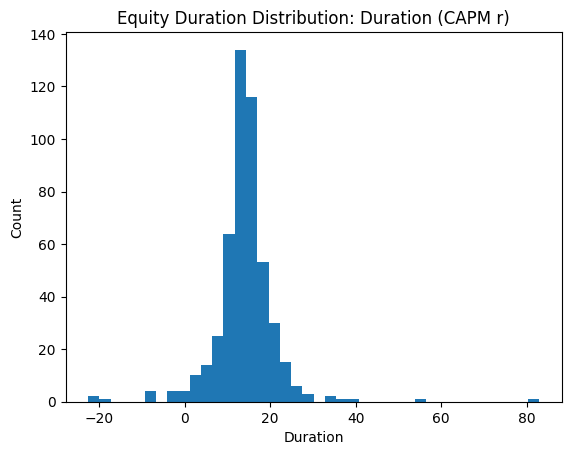

In [31]:
plt.figure()
plt.hist(df_dur[DUR_COL].dropna(), bins=40)
plt.title(f"Equity Duration Distribution: {DUR_COL}")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.show()

/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_6664/3481628179.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  evt_corr = tmp.groupby("date").apply(lambda g: g["AR"].corr(g[D])).reset_index(name="corr_AR_D")


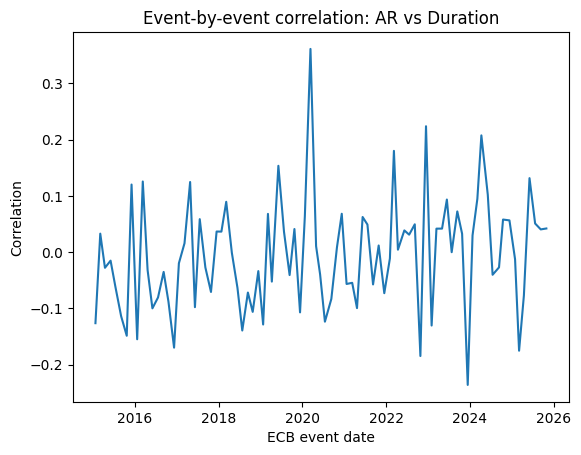

In [32]:
tmp = df_panel.dropna(subset=["AR", D]).copy()
evt_corr = tmp.groupby("date").apply(lambda g: g["AR"].corr(g[D])).reset_index(name="corr_AR_D")

plt.figure()
plt.plot(evt_corr["date"], evt_corr["corr_AR_D"])
plt.title("Event-by-event correlation: AR vs Duration")
plt.xlabel("ECB event date")
plt.ylabel("Correlation")
plt.show()

## 11. Saving the Outputs

In [33]:
OUT = DATA_DIR / "ecb_shocks_results"
OUT.mkdir(exist_ok=True)

# Save the final panel used
df_panel.to_parquet(OUT / "panel_event_day0.parquet", index=False)

# Save regression tables as text
with open(OUT / "reg_m1_baseline.txt", "w") as f:
    f.write(m1.summary().as_text())

with open(OUT / "reg_m2_two_shock.txt", "w") as f:
    f.write(m2.summary().as_text())

print("Saved to:", OUT)

Saved to: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/ecb_shocks_results
